In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Currently using {DEVICE}")

Currently using cuda


In [3]:
from src.data_import import load_fashion_mnist, load_mnist_digit, load_CIFAR10, load_olivetti

train_loader, test_loader = load_olivetti(2, shuffle=True)

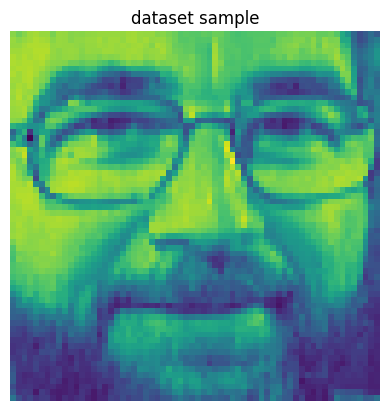

label: 27
shape: torch.Size([2, 1, 64, 64])


In [4]:
from src.plot import show_single_sample, show_grid

x_real, _ = next(iter(train_loader))
show_single_sample(x_real[0], "dataset sample", cmap="viridis")
#print label
print("label:", _[0].item())
print("shape:", x_real.shape)

In [5]:
from src.model import EnergyHead, EBM, SmallEBM

n_heads = 3
IMAGE_SHAPE = (1, 64, 64)

model = EBM(image_shape=IMAGE_SHAPE, mid_dim=150, n_heads=n_heads, batch_size=32)
for head in model.heads:
    head.to(DEVICE)

model.to(DEVICE)

TypeError: EBM.__init__() got an unexpected keyword argument 'mid_dim'

In [ ]:
from src.sampler import ReplaySampler
from src.information import TotalCorrelationEstimator

sampler = ReplaySampler(model, img_shape=IMAGE_SHAPE, buffer_size=600, noise_fraction=0.05, device=DEVICE)
total_correlation_estimator = TotalCorrelationEstimator(n_heads, hidden_dim=64)
total_correlation_estimator.to(DEVICE)

In [ ]:
from src.train import train_one_epoch_TC, train_one_epoch
#torch.autograd.set_detect_anomaly(True, check_nan=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.001, 0.999))

for epoch in range(8):
    epoch_loss = train_one_epoch(
        model, 
        sampler, 
        train_loader, 
        optimizer,
        sample_steps=40,
        sample_step_size=10.0,
        sample_noise_std=0.005,
        energy_reg=1e-1,
        corr_param=1e-2,
        device=DEVICE
    )
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

  0%|          | 0/140 [00:00<?, ?it/s]

100%|██████████| 140/140 [00:29<00:00,  4.73it/s]


  CD:     -0.0059
  Reg:    0.0205
  Corr:   0.0133
  E_real: -0.0298
  E_fake: -0.0311
  Gap:    0.0014
Epoch 1, Loss: 0.0279


100%|██████████| 140/140 [00:28<00:00,  4.87it/s]


  CD:     0.0017
  Reg:    0.0023
  Corr:   0.0133
  E_real: -0.0058
  E_fake: -0.0075
  Gap:    0.0017
Epoch 2, Loss: 0.0174


...

  CD:     0.0154
  Reg:    0.0085
  Corr:   0.0133
  E_real: 0.0082
  E_fake: -0.0077
  Gap:    0.0159
Epoch 7, Loss: 0.0372


100%|██████████| 140/140 [00:29<00:00,  4.81it/s]


  CD:     -0.0000
  Reg:    0.0009
  Corr:   0.0133
  E_real: -0.0030
  E_fake: -0.0030
  Gap:    0.0000
Epoch 8, Loss: 0.0143


 64%|██████▎   | 89/140 [00:19<00:10,  4.64it/s]


KeyboardInterrupt: 

EBM DIAGNOSTICS

[1] Energy on real data
  Train  →  mean=0.0859,  std=0.0473
  Test   →  mean=0.0837,  std=0.0467
  |E_test - E_train| = 0.0022  (ok)

[2] Energy on fake data (Langevin samples)
  Fake   →  mean=0.0026,  std=0.0748
  Gap (E_real_train - E_fake) = 0.0833  (WARNING: gap inverted)

[3] Energy on pure noise
  Noise  →  mean=3.1053,  std=0.0541
  Gap (E_real_train - E_noise) = -3.0193  (ok)

[4] Per-head energy (on train batch)
  Head 0  →  mean=0.3622,  std=0.0245
  Head 1  →  mean=0.4721,  std=0.0120
  Head 2  →  mean=-0.7918,  std=0.0096
  Max off-diagonal correlation: 1.0000  (WARNING: heads are correlated)

[5] Replay buffer
  Buffer size: 600 / 600
  Buffer samples  →  mean=0.5535,  std=0.1749,  min=-0.4970,  max=1.0000

[6] Visual samples (Langevin from noise)


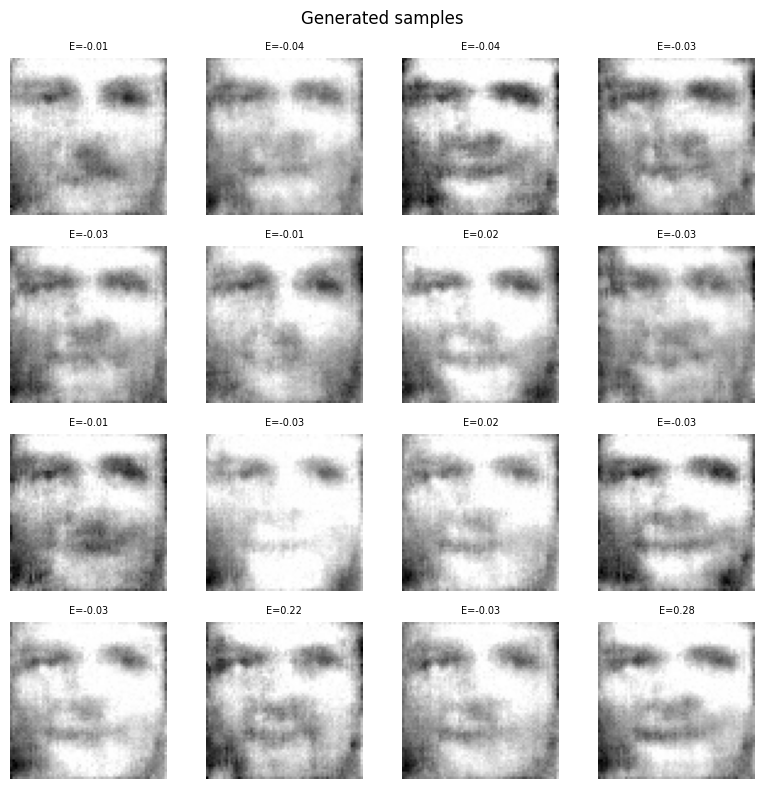


DONE


In [ ]:
from src.diagnostic import diagnose

diagnose(model, sampler, IMAGE_SHAPE, train_loader, test_loader, device=DEVICE, n_samples=16)

In [ ]:
samples = sampler.generate(10, steps=600, step_size=10.0, noise_std=0.005)

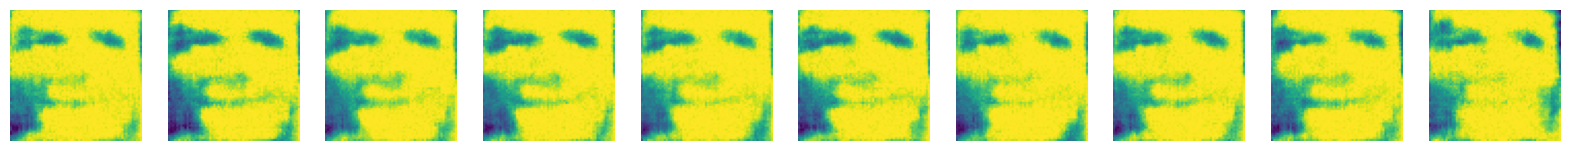

In [ ]:
show_grid(samples, 10)

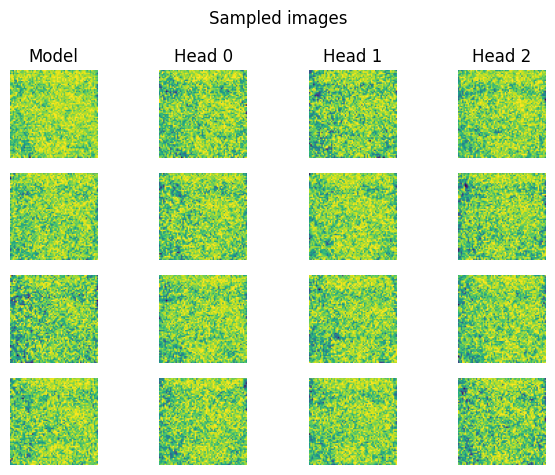

In [ ]:
from src.plot import visualize_heads

fig = visualize_heads(model, sampler.buffer, IMAGE_SHAPE, DEVICE, k=4, cmap="viridis")

In [ ]:
def visualize_head_gradients(model, x, device, idx=0):
    """
    Per una singola immagine, mostra dE_i/dx per ogni testa.
    Rivela cosa "guarda" ogni testa nell'immagine.
    """
    model.eval()
    img = x[idx].unsqueeze(0).to(device)  # (1, 1, 28, 28)

    n_heads = len(model.heads)
    fig, axes = plt.subplots(1, n_heads + 1, figsize=(3 * (n_heads + 1), 3))

    # Immagine originale
    axes[0].imshow(img.squeeze().cpu().numpy(), cmap="gray")
    axes[0].set_title("Input")
    axes[0].axis("off")

    for i, head in enumerate(model.heads):
        x_ = img.detach().requires_grad_(True)
        with torch.enable_grad():
            e = head(x_).sum()
            g = torch.autograd.grad(e, x_, only_inputs=True)[0]

        g_np = g.squeeze().cpu().detach().numpy()
        g_np = np.abs(g_np)
        g_np = (g_np - g_np.min()) / (g_np.max() - g_np.min() + 1e-8)

        axes[i + 1].imshow(g_np, cmap="hot")
        axes[i + 1].set_title(f"Head {i}\n|dE/dx|")
        axes[i + 1].axis("off")

    plt.suptitle("Gradient maps per testa", fontsize=12)
    plt.tight_layout()
    plt.show()

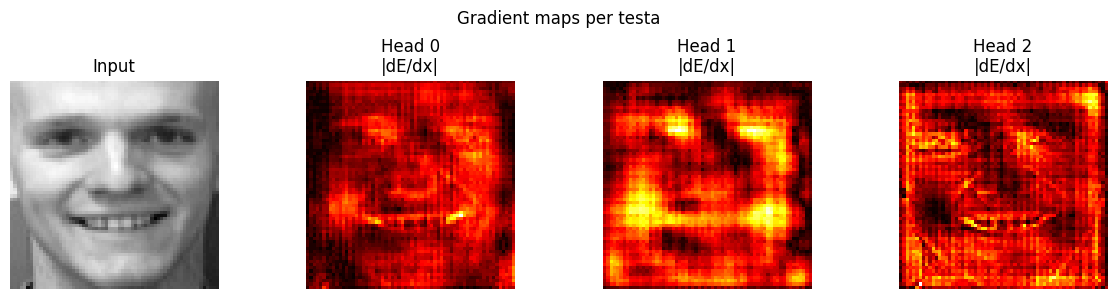

In [ ]:
it = iter(test_loader)
for _ in range(2):
    it.__next__()
x0 = it.__next__()[0]

visualize_head_gradients(model, x0, DEVICE)
